In [2]:
!pip install nilearn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 62.7 MB/s eta 0:00:00


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Load the preprocessed 4D fMRI image
smoothed_img = image.load_img('smoothed_normalized_cleaned_fmri_image.nii')

# Initialize NiftiLabelsMasker with the fetched 3D atlas
masker = NiftiLabelsMasker(labels_img=atlas_img, standardize=True)

# Compute the mean time series for each ROI
time_series = masker.fit_transform(smoothed_img)

# Save the time series data to a CSV file
np.savetxt('time_series.csv', time_series, delimiter=',')


####Playing with clean, normalize and smooth (rest)

In [3]:
import nilearn.image as image
import nilearn.plotting as plotting
import numpy as np
import nilearn.plotting as plotting
import matplotlib.pyplot as plt
from nilearn import datasets
from nilearn.image import smooth_img
from nilearn.image import clean_img
from nilearn.image import resample_to_img


(64, 64, 34, 150)
(176, 256, 256)


(64, 64, 34, 150)


/usr/local/lib/python3.10/dist-packages/nilearn/image/resampling.py:809: UserWarning: Casting data from int32 to float32
  return resample_img(


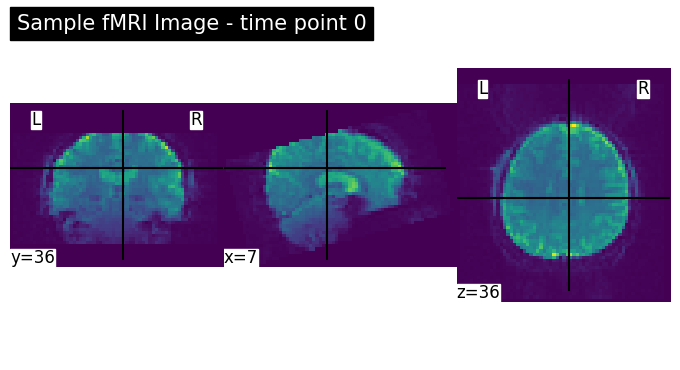

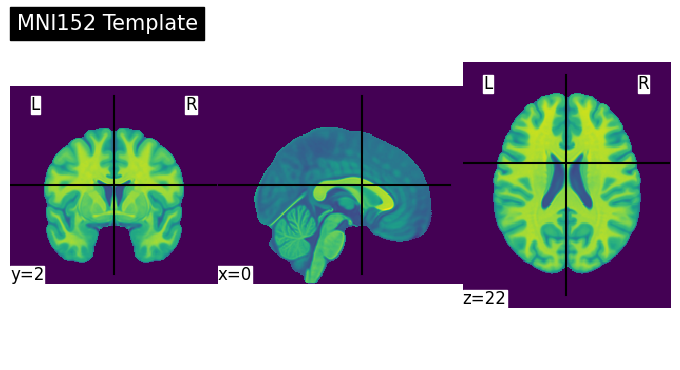

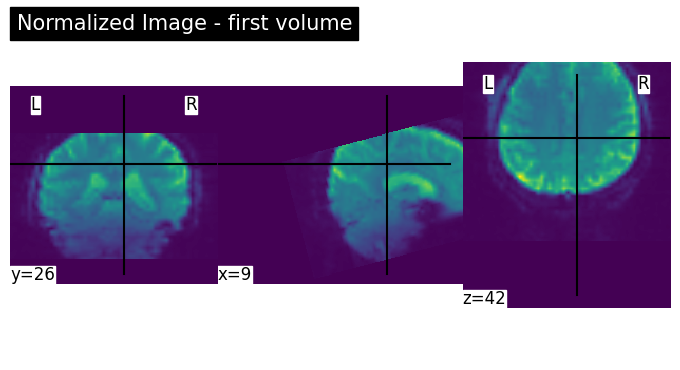

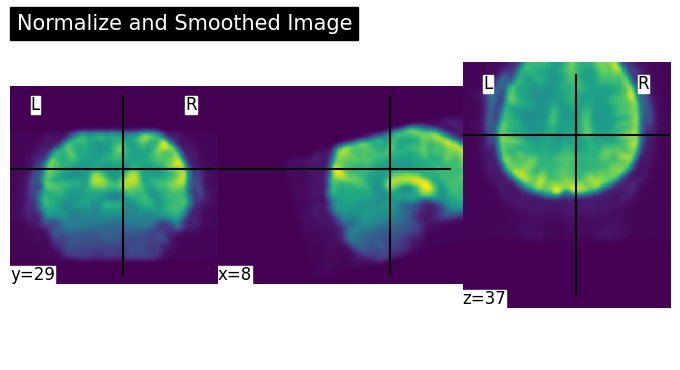

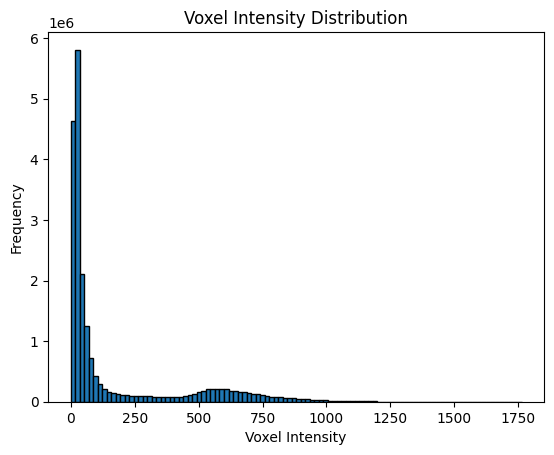

In [19]:
#REST
rest_img = image.load_img('/content/drive/MyDrive/UoM Autism Summer 2024/ABIDE MRI DATA (rest)/CALTECH/0051456/session_1/rest_1/rest.nii')
print(rest_img.shape)
# Extract the first volume (3D) from the 4D fMRI image
first_volume_rest = image.index_img(rest_img, 0)
plotting.plot_img(first_volume_rest, title='Sample fMRI Image - time point 0')
plotting.show()

#NORMALIZING - showing MNI152 template
# Load the MNI152 template
mni152_template = datasets.load_mni152_template()
plotting.plot_img(mni152_template, title='MNI152 Template')
plotting.show()

# NORMALIZE
# Resample the fMRI image to the template space
normalized_img = resample_to_img(first_volume_rest, mni152_template, interpolation='linear')
# PLOT NORMALIZED
plotting.plot_img(normalized_img, title='Normalized Image - first volume')
plotting.show()


#SMOOTH
smoothed_img = smooth_img(normalized_img, fwhm=6)  # 6mm full-width at half-maximum
smoothed_img.to_filename('smoothed_normalized_cleaned_rest_image.nii')
# PLOT SMOOTHED
plotting.plot_img(smoothed_img, title='Normalize and Smoothed Image')
plotting.show()

#PLOTTING HISTOGRAM....
# Load the 4D fMRI image
fmri_img = image.load_img('/content/drive/MyDrive/UoM Autism Summer 2024/ABIDE MRI DATA (rest)/CALTECH/0051456/session_1/rest_1/rest.nii')
# Extract data from the 4D fMRI image
data = fmri_img.get_fdata()
# Flatten the data and plot histogram
plt.hist(data.flatten(), bins=100, edgecolor='black')
plt.title('Voxel Intensity Distribution')
plt.xlabel('Voxel Intensity')
plt.ylabel('Frequency')
plt.show()


####Normalize mprage

(176, 256, 256)


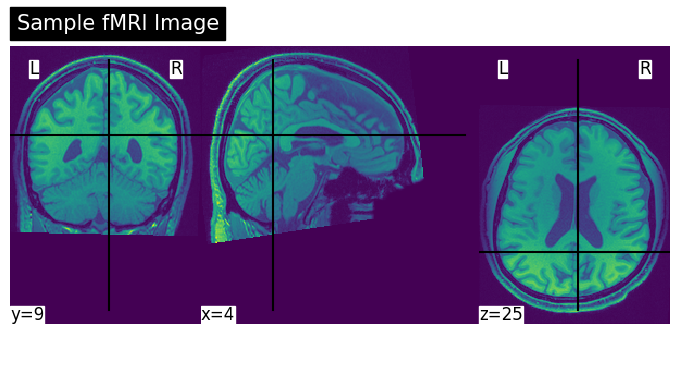

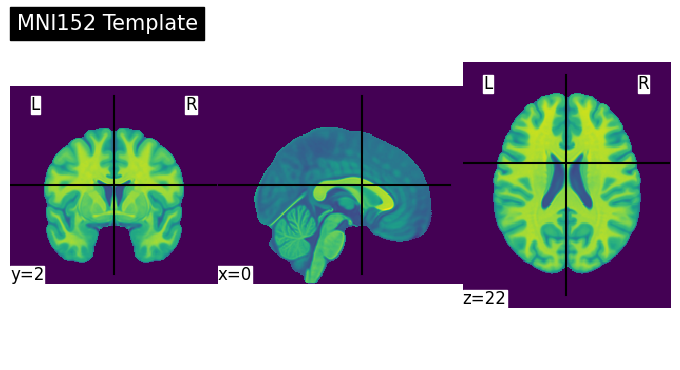

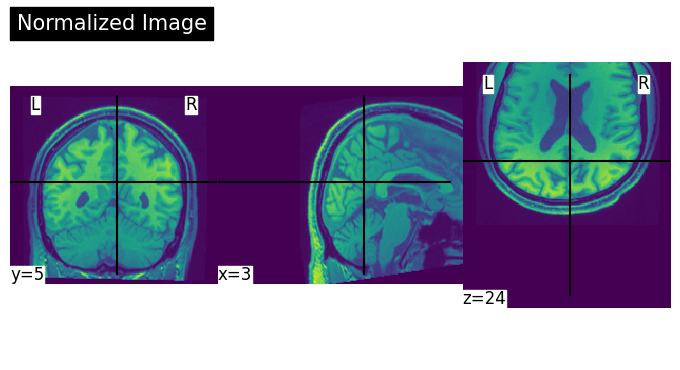

Shape normalized:  (197, 233, 189)


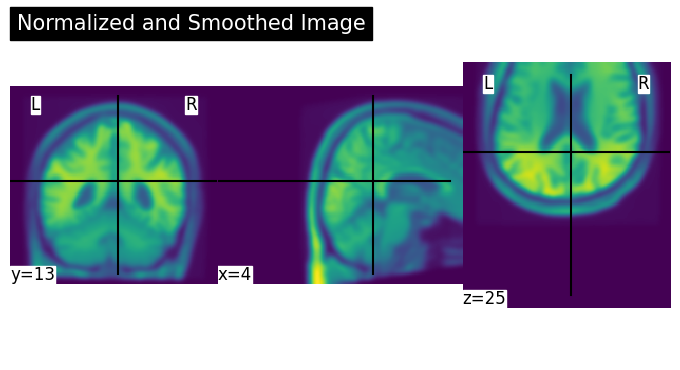

Shape final:  (197, 233, 189)


In [26]:
#EXAMPLE MPRAGE
mprage_img = image.load_img('/content/drive/MyDrive/UoM Autism Summer 2024/ABIDE_I_mprage_data/CALTECH_51456_ASD_mprage.nii.gz')
print(mprage_img.shape)
plotting.plot_img(mprage_img, title='Sample fMRI Image')
plotting.show()

#NORMALIZING - showing MNI152 template
# Load the MNI152 template
mni152_template = datasets.load_mni152_template()
plotting.plot_img(mni152_template, title='MNI152 Template')
plotting.show()

# NORMALIZE
# Resample the fMRI image to the template space
normalized_img = resample_to_img(mprage_img, mni152_template, interpolation='linear')
# PLOT CLEANED
plotting.plot_img(normalized_img, title='Normalized Image')
plotting.show()

print("Shape normalized: ", normalized_img.shape)

#SMOOTH
smoothed_img = smooth_img(normalized_img, fwhm=6)  # 6mm full-width at half-maximum
smoothed_img.to_filename('preprocessed_mprage.nii')
# PLOT SMOOTHED
plotting.plot_img(smoothed_img, title='Normalized and Smoothed Image')
plotting.show()
print("Shape final: ", smoothed_img.shape)


MPRAGE

####Atlas

Atlas file path: <class 'nibabel.nifti1.Nifti1Image'>
data shape (91, 109, 91, 48)
affine: 
[[   2.    0.    0.  -90.]
 [   0.    2.    0. -126.]
 [   0.    0.    2.  -72.]
 [   0.    0.    0.    1.]]
metadata:
<class 'nibabel.nifti1.Nifti1Header'> object, endian='<'
sizeof_hdr      : 348
data_type       : b''
db_name         : b''
extents         : 0
session_error   : 0
regular         : b''
dim_info        : 0
dim             : [  4  91 109  91  48   1   1   1]
intent_p1       : 0.0
intent_p2       : 0.0
intent_p3       : 0.0
intent_code     : none
datatype        : uint8
bitpix          : 8
slice_start     : 0
pixdim          : [1. 2. 2. 2. 1. 1. 1. 1.]
vox_offset      : 0.0
scl_slope       : nan
scl_inter       : nan
slice_end       : 0
slice_code      : unknown
xyzt_units      : 0
cal_max         : 0.0
cal_min         : 0.0
slice_duration  : 0.0
toffset         : 0.0
glmax           : 0
glmin           : 0
descrip         : b''
aux_file        : b''
qform_code      : unknown
sform

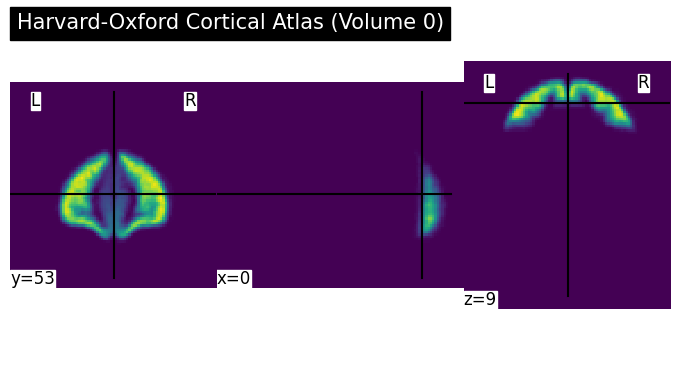

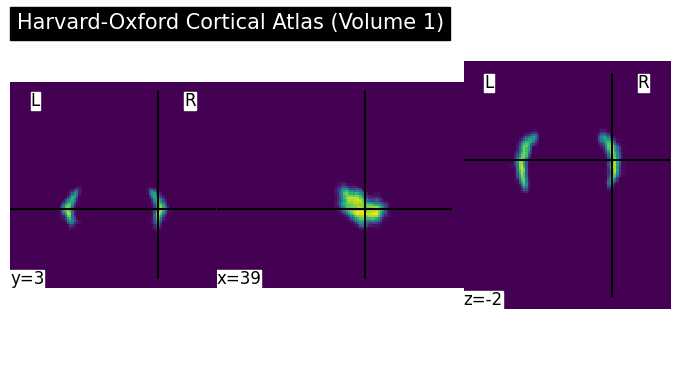

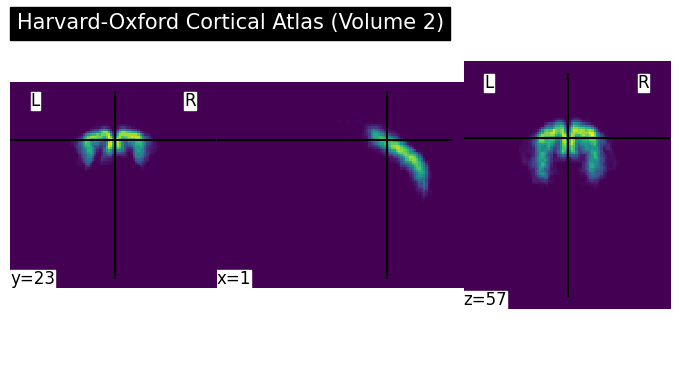

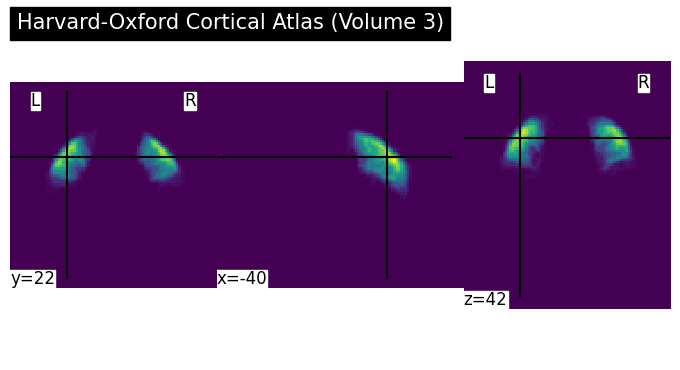

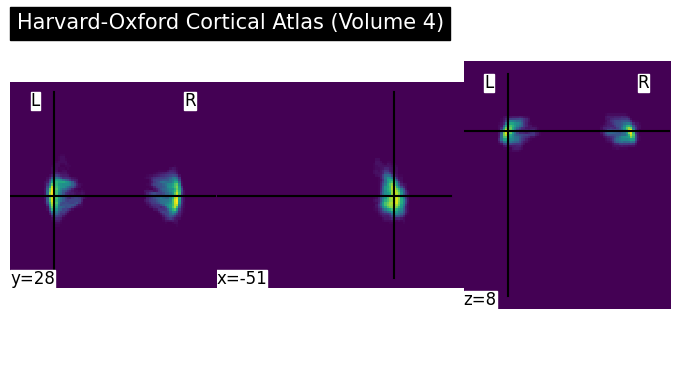

(64, 64, 34, 150)


/usr/local/lib/python3.10/dist-packages/nilearn/image/resampling.py:809: UserWarning: Casting data from int32 to float32
  return resample_img(


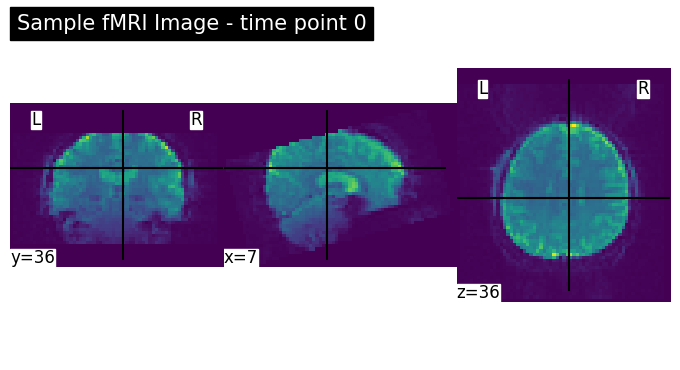

DimensionError: Input data has incompatible dimensionality: Expected dimension is 3D and you provided a 4D image. See https://nilearn.github.io/stable/manipulating_images/input_output.html.

In [30]:
from nilearn.regions import Parcellations
from nilearn import datasets
from nilearn.input_data import NiftiLabelsMasker
from nilearn import image, plotting
from nilearn import datasets

# Fetch the Harvard-Oxford Cortical Atlas
atlas = datasets.fetch_atlas_harvard_oxford('cort-prob-2mm')

# Get the atlas file path
atlas_filename = atlas['maps']

# Print atlas details
print(f"Atlas file path: {atlas_filename}")

# Load the atlas image
atlas_img = image.load_img(atlas_filename)

# Select a specific volume (e.g., the first one) from the 4D image

for x in range (0, 5):
  first_volume = image.index_img(atlas_img, x)
  # Plot the selected volume from the atlas
  plotting.plot_img(first_volume, title=f'Harvard-Oxford Cortical Atlas (Volume {x})')
  plotting.show()

# Initialize NiftiLabelsMasker with the fetched 3D atlas
masker = NiftiLabelsMasker(labels_img=atlas_img, standardize=True)

#REST
rest_img = image.load_img('/content/drive/MyDrive/UoM Autism Summer 2024/ABIDE MRI DATA (rest)/CALTECH/0051456/session_1/rest_1/rest.nii')
print(rest_img.shape)
# Extract the first volume (3D) from the 4D fMRI image
first_volume_rest = image.index_img(rest_img, 0)
plotting.plot_img(first_volume_rest, title='Sample fMRI Image - time point 0')
plotting.show()


# Compute the mean time series for each ROI
time_series = masker.fit_transform(rest_img)

# Save the time series data to a CSV file
np.savetxt('time_series.csv', time_series, delimiter=',')

/usr/local/lib/python3.10/dist-packages/nilearn/image/resampling.py:809: UserWarning: Casting data from int32 to float32
  return resample_img(


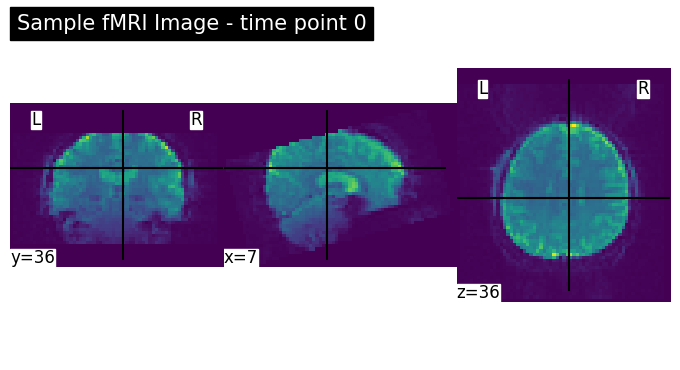

Shape of fMRI image: (64, 64, 34, 150)
Shape of atlas image: (91, 109, 91, 48)


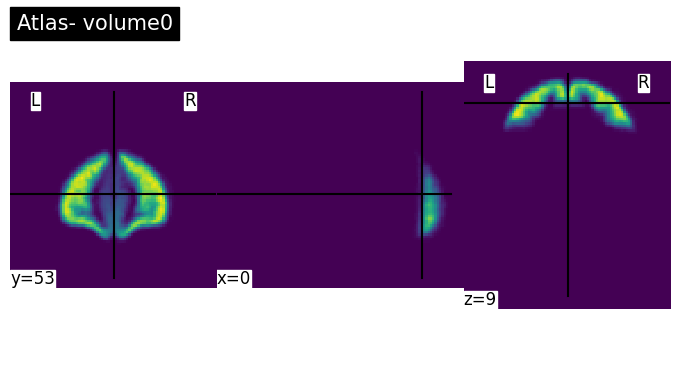

Shape of resampled atlas image:  (64, 64, 34, 48)


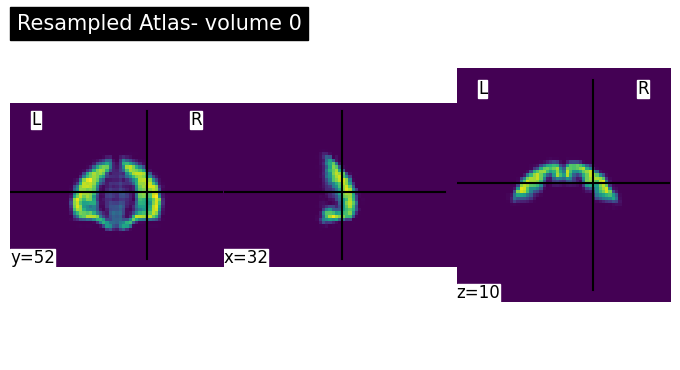

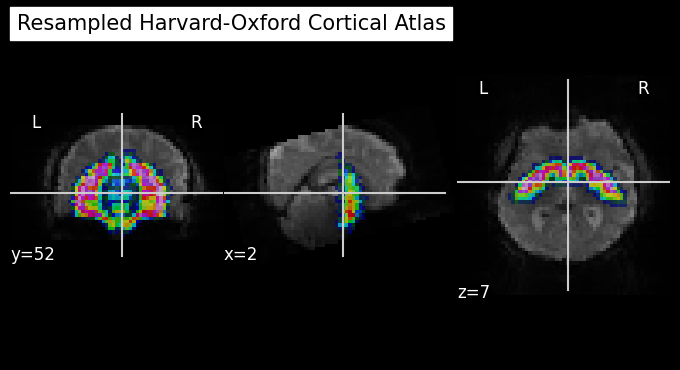

In [45]:
from nilearn import datasets, image, masking, plotting
import nibabel as nib
import numpy as np
import pandas as pd

# Load the fMRI image
fmri_img = image.load_img('/content/drive/MyDrive/UoM Autism Summer 2024/ABIDE MRI DATA (rest)/CALTECH/0051456/session_1/rest_1/rest.nii')
first_volume_fmri = image.index_img(fmri_img, 0)
plotting.plot_img(first_volume_fmri, title='Sample fMRI Image - time point 0')
plotting.show()
# Print the shape of the fMRI image to understand its dimensions
print(f"Shape of fMRI image: {fmri_img.shape}")


# Load the Harvard-Oxford Cortical Atlas
atlas = datasets.fetch_atlas_harvard_oxford('cort-prob-2mm')
# Get the atlas file path
atlas_filename = atlas['maps']
atlas_labels = atlas['labels']
# Load the atlas image
atlas_img = image.load_img(atlas_filename)
print(f"Shape of atlas image: {atlas_img.shape}")
atlas_image_0 = image.index_img(atlas_img, 0)
plotting.plot_img(atlas_image_0, title='Atlas- volume0')
plotting.show()


# Resample the atlas to the fMRI image space
resampled_atlas_img = image.resample_to_img(atlas_img, fmri_img, interpolation='nearest')
print("Shape of resampled atlas image: ", resampled_atlas_img.shape)
#plot first volume
first_volume_atlas_resampled = image.index_img(resampled_atlas_img, 0)
plotting.plot_img(first_volume_atlas_resampled, title='Resampled Atlas- volume 0')
plotting.show()


# Plot the resampled atlas on top of a mean image of the fMRI data
mean_fmri_img = image.mean_img(fmri_img)
plotting.plot_roi(first_volume_atlas_resampled, bg_img=mean_fmri_img, title='Resampled Harvard-Oxford Cortical Atlas')
plotting.show()




In [56]:
from nilearn import datasets, image, masking, plotting
import numpy as np
import pandas as pd

# Load the fMRI image
fmri_img = image.load_img('/content/drive/MyDrive/UoM Autism Summer 2024/ABIDE MRI DATA (rest)/CALTECH/0051456/session_1/rest_1/rest.nii')
print(f"Shape of fMRI image: {fmri_img.shape}")

# Load the Harvard-Oxford Cortical Atlas
atlas = datasets.fetch_atlas_harvard_oxford('cort-prob-2mm')
atlas_filename = atlas['maps']
atlas_labels = atlas['labels']
atlas_img = image.load_img(atlas_filename)
print(f"Shape of atlas image: {atlas_img.shape}")

# Resample the atlas to the fMRI image space
resampled_atlas_img = image.resample_to_img(atlas_img, fmri_img, interpolation='nearest')
print("Shape of resampled atlas image: ", resampled_atlas_img.shape)

resampled_atlas_img_0 = image.index_img(resampled_atlas_img, 0)
# Calculate the mean image from the fMRI data
mean_fmri_img = image.mean_img(fmri_img)
plotting.plot_roi(resampled_atlas_img_0, bg_img=mean_fmri_img, title='Resampled Harvard-Oxford Cortical Atlas')
plotting.show()

# Get unique labels from the resampled atlas
resampled_atlas_data = resampled_atlas_img_0.get_fdata()
unique_labels = np.unique(resampled_atlas_img_0)
unique_labels = unique_labels[unique_labels != 0]  # Exclude background if needed

# Initialize a list to store the masked time series
time_series_by_region = []

for label in unique_labels:
    # Create a binary mask for the current label
    binary_mask = (resampled_atlas_data == label).astype(int)
    binary_mask_img = image.new_img_like(resampled_atlas_img, binary_mask)

    # Apply the binary mask to the entire fMRI data
    masked_data = masking.apply_mask(fmri_img, binary_mask_img)

    if masked_data.size == 0:
        # Skip if the mask is invalid or results in an empty time series
        print(f"Mask for label {label} resulted in empty masked data.")
        continue

    # Calculate the mean time series for this region
    mean_time_series = np.mean(masked_data, axis=0)
    time_series_by_region.append(mean_time_series)

# Create a DataFrame with the time series data for easier handling
time_series_df = pd.DataFrame(np.array(time_series_by_region).T, columns=atlas_labels[1:])  # Skip the first label (background)

# Display the first few rows of the DataFrame
print(time_series_df.head())


Shape of fMRI image: (64, 64, 34, 150)
Shape of atlas image: (91, 109, 91, 48)
Shape of resampled atlas image:  (64, 64, 34, 48)


<ipython-input-56-fb355bd19c03>:37: UserWarning: Data array used to create a new image contains 64-bit ints. This is likely due to creating the array with numpy and passing `int` as the `dtype`. Many tools such as FSL and SPM cannot deal with int64 in Nifti images, so for compatibility the data has been converted to int32.
  binary_mask_img = image.new_img_like(resampled_atlas_img, binary_mask)


ValueError: The mask is invalid as it is empty: it masks all data.

####Trying preprocessed data


Script usage:
python download_abide_preproc.py -d <derivative> -p <pipeline>
                                     -s <strategy> -o <out_dir>
                                     [-lt <less_than>] [-gt <greater_than>]
                                     [-x <sex>] [-t <site>]

In [ ]:
!python download_abide_preproc.py -d rois_aal -p cpac -s nofilt_noglobal -o /content/data

In [58]:
file_path = "/content/data/Outputs/cpac/nofilt_noglobal/rois_aal/Pitt_0050004_rois_aal.1D"

In [61]:
import os
import nibabel as nib
import numpy as np
def convert_1d_to_nifti(input_dir, output_dir):
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)

    for file in os.listdir(input_dir):
        if file.endswith('.1D'):
            print(f"Processing file: {file}")
            input_file = os.path.join(input_dir, file)
            output_file = os.path.join(output_dir, file.replace('.1D', '.nii.gz'))

            data = np.loadtxt(input_file)
            data = data.reshape(data.shape[0], 1, 1, -1)
            nifti_img = nib.Nifti1Image(data, np.eye(4))
            nib.save(nifti_img, output_file)
            print(f"Saved file: {output_file}")

            # Remove the '.1D' file after successful conversion
            os.remove(input_file)
            print(f"Removed file: {input_file}")


convert_1d_to_nifti("/content/data/Outputs/cpac/nofilt_noglobal/rois_aal", "/content/1D_to_nii")

Processing file: Pitt_0050004_rois_aal.1D
Saved file: /content/1D_to_nii/Pitt_0050004_rois_aal.nii.gz
Removed file: /content/data/Outputs/cpac/nofilt_noglobal/rois_aal/Pitt_0050004_rois_aal.1D
Processing file: Pitt_0050006_rois_aal.1D
Saved file: /content/1D_to_nii/Pitt_0050006_rois_aal.nii.gz
Removed file: /content/data/Outputs/cpac/nofilt_noglobal/rois_aal/Pitt_0050006_rois_aal.1D
Processing file: Pitt_0050009_rois_aal.1D
Saved file: /content/1D_to_nii/Pitt_0050009_rois_aal.nii.gz
Removed file: /content/data/Outputs/cpac/nofilt_noglobal/rois_aal/Pitt_0050009_rois_aal.1D
Processing file: Pitt_0050005_rois_aal.1D
Saved file: /content/1D_to_nii/Pitt_0050005_rois_aal.nii.gz
Removed file: /content/data/Outputs/cpac/nofilt_noglobal/rois_aal/Pitt_0050005_rois_aal.1D
Processing file: Pitt_0050007_rois_aal.1D
Saved file: /content/1D_to_nii/Pitt_0050007_rois_aal.nii.gz
Removed file: /content/data/Outputs/cpac/nofilt_noglobal/rois_aal/Pitt_0050007_rois_aal.1D
Processing file: Pitt_0050008_rois_

(196, 1, 1, 116)


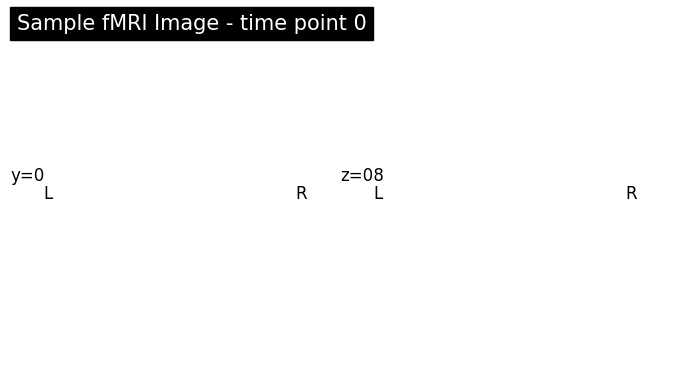

In [68]:
file_path = "/content/1D_to_nii/Pitt_0050004_rois_aal.nii.gz"
rest_img = image.load_img(file_path)
print(rest_img.shape)
# Extract the first volume (3D) from the 4D fMRI image
first_volume_rest = image.index_img(rest_img, 0)
plotting.plot_img(first_volume_rest, title='Sample fMRI Image - time point 0')
plotting.show()
